In [1]:
# ==============================================================================
# EXTERNAL FORGE: ENVIRONMENT HYGIENE
# ==============================================================================
print("🏗️ Preparando cimientos del Colab Externo...")

# Forzamos la actualización de tipos de datos y eliminamos conflictos
!pip install --upgrade ml_dtypes -q
!pip install h3 dtreeviz -q

print("✅ Entorno listo. Procediendo a Montar Drive y Auth.")

🏗️ Preparando cimientos del Colab Externo...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 10.1 MB/s eta 0:00:00
✅ Entorno listo. Procediendo a Montar Drive y Auth.


In [2]:
# ==============================================================================
# CELL 0: PIENZA CLOUD BOOTSTRAP (EXTERNAL FORGE EDITION)
# ==============================================================================
# Environment: Public Google Colab (External Forge)
# Purpose: Manual Authentication to bridge into BigQuery from outside.
# ==============================================================================

# --- 1. CLOUD PASSPORT (OBLIGATORIO EN COLAB EXTERNO) ---
from google.colab import auth, drive
print("🔐 Solicitando Pasaporte de Google Cloud...")
auth.authenticate_user() # Esto abrirá una ventana emergente para que elijas tu cuenta
print("✅ Autenticación de Usuario Exitosa.")

print("\n📂 Montando Bóveda de Drive...")
drive.mount('/content/drive') # Necesario para guardar el modelo al final
print("✅ Drive Sincronizado.")

# --- 2. CORE IMPORTS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
import warnings
warnings.filterwarnings('ignore')

# --- 3. CLOUD CONNECTIVITY ---
# --- SOVEREIGN COORDINATES ---
PROJECT_ID    = '645009831643'
DATASET_CORE  = 'pienza_mini'

try:
    # El cliente ahora usará tus credenciales de usuario recién validadas
    client = bigquery.Client(project=PROJECT_ID)
    print(f"✅ Cliente BigQuery Activo: {PROJECT_ID}")

    # Prueba de conexión
    probe_query = f"SELECT COUNT(*) FROM `{PROJECT_ID}.{DATASET_CORE}.offers`"
    client.query(probe_query).result()
    print("✅ Sovereign Data Connection: STABLE.")
except Exception as e:
    print(f"🔴 CRITICAL: Cloud connection failed. Details: {e}")

# --- 4. VISUAL CANON ---
PIENZA_PURPLE = '#440154'
PIENZA_TEAL   = '#21918c'
PIENZA_GREY   = '#FAFAFA'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': PIENZA_GREY,
    'axes.facecolor': PIENZA_GREY,
    'axes.titlecolor': PIENZA_PURPLE,
    'figure.titlesize': 24,
    'figure.titleweight': 'bold'
})

print("\n--- EXTERNAL FORGE SYSTEM READY ---")

🔐 Solicitando Pasaporte de Google Cloud...
✅ Autenticación de Usuario Exitosa.

📂 Montando Bóveda de Drive...
Mounted at /content/drive
✅ Drive Sincronizado.
✅ Cliente BigQuery Activo: 645009831643
✅ Sovereign Data Connection: STABLE.

--- EXTERNAL FORGE SYSTEM READY ---


In [3]:
# ==============================================================================
# CELL 1: DATA INGESTION (THE PIENZA WAREHOUSE SOURCE)
# ==============================================================================
# Purpose: Extract the high-fidelity 'Silver Layer' from BigQuery.
#          This is the raw material for the Pienza Manifold Forge.
# ==============================================================================

def ingest_pienza_gold():
    # USAMOS DATASET_CORE (pienza_mini) para la fuente de verdad
    print(f"📡 Ingesting Master View from {PROJECT_ID}.{DATASET_CORE}...")

    # Query la vista que une todo (Física + Features + Geografía)
    query = f"""
        SELECT *
        FROM `{PROJECT_ID}.{DATASET_CORE}.v_ML_Supervised`
        WHERE upfront_fare IS NOT NULL
    """

    try:
        # Nota: 'client' debe haber sido inicializado en la Cell 0
        df = client.query(query).to_dataframe()
        print(f"✅ Ingestion Successful: {len(df):,} records loaded into memory.")
        return df
    except Exception as e:
        print(f"🔴 INGESTION FAILED: {e}")
        print("   Verify that Cell 0 was executed and DATASET_CORE is defined.")
        return None

# EXECUTE
df_raw = ingest_pienza_gold()
if df_raw is not None:
    display(df_raw.head())

📡 Ingesting Master View from 645009831643.pienza_mini...
✅ Ingestion Successful: 4,765 records loaded into memory.


,offer_id,session_fk,ocr_fk,image_content_hash,offer_timestamp,upfront_fare,time_to_pickup_sec,dist_to_pickup_km,est_trip_time_sec,est_trip_dist_km,...,dropoff_polygon_id,dropoff_polygon_name,dropoff_h3_hex_id,dropoff_hdbscan_id,dropoff_hdbscan_name,realized_traffic_index,historical_rolling_avg_traffic_index,traffic_volatility_index_ml,traffic_volatility_index_eda,heuristic_flag_context
0,OF00001,SID0001,OCR00001,6f53fbeb55d097dbd8c1087a537cbe4589a05eaea7398d...,2025-08-22 06:44:33,204.24,840.0,4.9,2580.0,22.1,...,-1,unassigned,89499516bafffff,-1,unassigned,None,None,None,None,None
1,OF00002,SID0001,OCR00002,fe824e63f500f8c99f017cc6d975d087f9d529e7a26997...,2025-08-22 06:45:06,173.86,300.0,1.5,2400.0,24.3,...,-1,unassigned,894995b1dd7ffff,-1,unassigned,None,None,None,None,None
2,OF00003,SID0001,OCR00003,64f34e64aaed7113e732d1434d857ac4de639b89626cf4...,2025-08-22 06:45:28,136.53,NaN,NaN,NaN,NaN,...,-1,unassigned,None,-2,missing_coordinates,None,None,None,None,None
3,OF00005,SID0001,OCR00005,3e028cf71edcd497a6dbd224b916da9a4ab024653e8409...,2025-08-22 07:25:22,95.27,420.0,1.7,1080.0,6.6,...,-1,unassigned,894995bab23ffff,-1,unassigned,None,None,None,None,None
4,OF00006,SID0001,OCR00006,ba2224442cb5087e9344dbe58dd87e877cb0d390935ae3...,2025-08-22 07:25:39,68.36,60.0,0.1,960.0,10.3,...,-1,unassigned,894995a31d7ffff,6,lomas_verdes,None,None,None,None,None


In [9]:
# ==============================================================================
# CELL 6: THE PIENZA GENOME REFINERY (v4.4 - STRICT PHYSICS & GEO ENABLED)
# ==============================================================================
# Protocol: Drop Bad Physics + Oversample Black + V4 Flags + FULL GEOGRAPHY
# ==============================================================================
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import sys
import subprocess

# --- 0. GEOSPATIAL ENGINE CHECK ---
try:
    import h3
except ImportError:
    print("🌐 Instalando librería H3 para geolocalización...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "h3", "-q"])
    import h3

def execute_pienza_forge_v4_strict(df_raw_source):
    print("🧪 INICIANDO REFINERÍA V4.4 (STRICT PHYSICS + GEO)...")
    print("="*75)

    df = df_raw_source.copy()
    n_start = len(df)

    # --- 1. SANEAMIENTO FÍSICO (STRICT DROP) ---
    # Eliminamos filas sin física válida (Tiempo/Distancia/Tarifa nulos o cero)
    CORE_PHYSICS = ['est_trip_time_sec', 'est_trip_dist_km', 'upfront_fare',
                    'time_to_pickup_sec', 'dist_to_pickup_km',
                    'pickup_lat', 'pickup_lon', 'dropoff_lat', 'dropoff_lon']

    df = df.dropna(subset=CORE_PHYSICS)
    # Anti-Teletransportación
    df = df[(df['est_trip_time_sec'] > 0) & (df['est_trip_dist_km'] > 0)].copy()

    n_physics = len(df)
    print(f"🛡️  SANEAMIENTO FÍSICO: {n_start - n_physics} filas corruptas eliminadas.")

    # --- 2. CONSOLIDACIÓN DE PRODUCTOS ---
    df['product_category_fk'] = df['product_category_fk'].replace(3, 2).replace(4, 3)
    df = df[df['product_category_fk'].isin([1, 2, 3])].copy()

    # --- 3. INGENIERÍA TEMPORAL Y GEOESPACIAL (CRÍTICO) ---
    df['offer_timestamp'] = pd.to_datetime(df['offer_timestamp'])

    # Tiempo
    df['hour_of_day'] = df['offer_timestamp'].dt.hour
    df['day_of_week'] = df['offer_timestamp'].dt.dayofweek

    # Geografía: Pickup (H3)
    # Usamos resolución 6 para capturar vecindarios generales
    df['pickup_h3_id'] = df.apply(lambda x: h3.latlng_to_cell(x['pickup_lat'], x['pickup_lon'], 6), axis=1)

    # Geografía: Dropoff (Topología "Salchichota")
    id_map = {-1:-1, 41:0, 42:0, 46:0, 43:1, 65:2, 62:2, 44:2, 36:2, 49:3, 52:3, 35:3, 50:4, 58:4, 25:5, 31:5, 63:6, 39:6, 51:7, 33:7, 37:8, 53:8, 48:8, 60:9, 57:10, 12:10, 32:10, 24:11, 40:12, 45:13, 59:13, 61:14, 38:14, 34:15, 30:16, 66:16, 17:17, 14:17, 22:17, 16:18, 13:18, 11:19, 15:20, 21:21, 20:21, 19:21, 18:22, 47:23, 55:23, 56:23, 54:24, 64:24, 71:25, 9:26, 70:27, 69:28, 8:29, 6:30, 7:30, 23:30, 3:31, 2:32, 4:33, 29:33, 68:34, 5:35, 27:36, 28:36, 1:37, 10:38, 0:39, 26:40, 67:41}
    df['id_agrupado'] = df['dropoff_polygon_id'].fillna(-1).astype(int).map(id_map).fillna(-1)

    # Lógica híbrida: Polygon ID > HDBSCAN ID
    conditions = [(df['id_agrupado'] >= 0), (df['dropoff_hdbscan_id'] > -1)]
    choices = ["P_" + df['id_agrupado'].astype(str), "C_" + df['dropoff_hdbscan_id'].astype(str)]
    df['dropoff_zone_id'] = np.select(conditions, choices, default="Unassigned")

    df['reason_primary_fk'] = df['reason_primary_fk'].fillna(99).astype(int)

    print(f"🗺️  GEOGRAFÍA ASIGNADA: {df['pickup_h3_id'].nunique()} Hexágonos H3 | {df['dropoff_zone_id'].nunique()} Zonas de Destino.")

    # --- 4. TAMIZ 3-SIGMA (Protección Black) ---
    z_scores = np.abs(stats.zscore(df['eph_direct_index'].fillna(0)))
    mask_to_drop = (z_scores >= 3) & (df['product_category_fk'] != 3)
    df = df[~mask_to_drop].copy()

    # --- 5. OVERSAMPLING ESTRATÉGICO ---
    df_black = df[df['product_category_fk'] == 3]
    if len(df_black) > 0:
        n_black = len(df_black)
        df = pd.concat([df] + [df_black]*14, ignore_index=True)
        print(f"📈 OVERSAMPLING: Black amplificado ({n_black} -> {n_black*15}).")

    # --- 6. INGENIERÍA DE INCENTIVOS (Flags V4) ---
    incentive_cols = ['surge_amount', 'turbo_plus_amount']
    flag_cols = ['is_surge', 'is_turbo']

    for amt_col, flag_col in zip(incentive_cols, flag_cols):
        df[amt_col] = df[amt_col].fillna(0.0)
        df[flag_col] = (df[amt_col] > 0.5).astype(int) # Flag explícito

    # --- 7. TRANSFORMACIONES (Log-Space) ---
    cols_to_log = ['upfront_fare', 'est_trip_dist_km'] + incentive_cols
    df[cols_to_log] = df[cols_to_log].fillna(0.0)
    for col in cols_to_log:
        df[col] = np.log1p(df[col])

    # --- 8. PREPARACIÓN FINAL ---
    # PHYSICS (7): Variables numéricas continuas
    PHYSICS_COLS = ['upfront_fare', 'est_trip_time_sec', 'est_trip_dist_km', 'time_to_pickup_sec', 'dist_to_pickup_km'] + incentive_cols

    # FLAGS (2): Variables binarias de incentivos
    FLAGS_COLS = flag_cols

    # SWITCHES (6): Condiciones de entrada (Incluye GEO)
    SWITCH_COLS = ['hour_of_day', 'day_of_week', 'product_category_fk', 'dropoff_zone_id', 'pickup_h3_id', 'reason_primary_fk']

    # Encoders
    label_encoders = {}
    for col in SWITCH_COLS:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

    # Scalers
    physics_scaler = MinMaxScaler(feature_range=(-1, 1))
    df[PHYSICS_COLS] = physics_scaler.fit_transform(df[PHYSICS_COLS])

    final_df = df[SWITCH_COLS + PHYSICS_COLS + FLAGS_COLS].copy()

    if final_df.isna().any().any():
        print("🔴 ERROR CRÍTICO: NaNs persistentes. Revisa la limpieza.")
        display(final_df.isna().sum())
    else:
        print(f"🏆 GENOMA V4.4 LISTO: {len(final_df):,} registros | Física Saneada.")
        print(f"   - Inputs (Switches): {len(SWITCH_COLS)} (Incluye H3 + Topología)")
        print(f"   - Outputs (Physics+Flags): {len(PHYSICS_COLS)} + {len(FLAGS_COLS)} = {len(PHYSICS_COLS)+len(FLAGS_COLS)}")

    return final_df, label_encoders, physics_scaler, SWITCH_COLS, PHYSICS_COLS, FLAGS_COLS

# EXECUTE
df_gan_ready, label_encoders, physics_scaler, SWITCH_COLS, PHYSICS_COLS, FLAGS_COLS = execute_pienza_forge_v4_strict(df_raw)
display(df_gan_ready.head())

🧪 INICIANDO REFINERÍA V4.4 (STRICT PHYSICS + GEO)...
🛡️  SANEAMIENTO FÍSICO: 29 filas corruptas eliminadas.
🗺️  GEOGRAFÍA ASIGNADA: 31 Hexágonos H3 | 67 Zonas de Destino.
📈 OVERSAMPLING: Black amplificado (37 -> 555).
🏆 GENOMA V4.4 LISTO: 5,064 registros | Física Saneada.
   - Inputs (Switches): 6 (Incluye H3 + Topología)
   - Outputs (Physics+Flags): 7 + 2 = 9


,hour_of_day,day_of_week,product_category_fk,dropoff_zone_id,pickup_h3_id,reason_primary_fk,upfront_fare,est_trip_time_sec,est_trip_dist_km,time_to_pickup_sec,dist_to_pickup_km,surge_amount,turbo_plus_amount,is_surge,is_turbo
0,14,4,0,66,27,0,-0.003427,-0.652174,0.085723,-0.034483,-0.455556,0.555808,-1.0,1,0
1,14,4,0,66,28,0,-0.084232,-0.678261,0.121845,-0.655172,-0.833333,-0.066903,-1.0,1,0
2,15,4,1,66,28,0,-0.385285,-0.869565,-0.355689,-0.517241,-0.811111,0.250417,-1.0,1,0
3,15,4,0,20,28,0,-0.550657,-0.886957,-0.198191,-0.931034,-0.988889,-0.066903,-1.0,1,0
4,15,4,0,37,28,2,-0.530904,-0.886957,-0.529966,-0.310345,-0.644444,0.018316,-1.0,1,0


In [10]:
# ==============================================================================
# CELL 7: THE GENERATOR V4.4 ARCHITECTURE (GEO-AWARE & HYBRID OUTPUT)
# ==============================================================================
# Purpose: Generate 7 Physical vars + 2 Flags, conditioned on Time & GEO (H3/Zones).
# ==============================================================================
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
import numpy as np

LATENT_DIM = 100

# --- 1. SINCRONIZACIÓN CON REFINERÍA (Cell 6) ---
# Recuperamos dimensiones dinámicamente del dataframe procesado
# Esto asegura que H3 y Zonas tengan sus embeddings del tamaño correcto.
vocab_sizes = {col: int(df_gan_ready[col].max() + 1) for col in SWITCH_COLS}
PHYSICS_DIM = len(PHYSICS_COLS) # 7 (5 Base + 2 Incentivos)
FLAGS_DIM = len(FLAGS_COLS)     # 2 (IsSurge, IsTurbo)

def build_generator_pienza_v4(latent_dim, vocab_sizes):
    # --- A. INPUTS (RUIDO + CONTEXTO) ---
    noise_input = Input(shape=(latent_dim,), name='noise_input')

    cat_inputs = []
    cat_embeddings = []

    # Iteramos sobre TODOS los Switches (Hora, Dia, Producto, H3, Zona, Reason)
    for col, v_size in vocab_sizes.items():
        i = Input(shape=(1,), name=f'input_{col}')
        cat_inputs.append(i)

        # Regla Log2: Si el vocabulario es grande (ej. H3 tiene 50 ids),
        # el embedding será de tamaño log2(50)+2 ≈ 7 dimensiones.
        emb_dim = int(np.log2(v_size) + 2) if v_size > 1 else 2

        emb = layers.Embedding(v_size, emb_dim, name=f'emb_{col}')(i)
        emb = layers.Flatten()(emb)
        cat_embeddings.append(emb)

    # Fusionamos Ruido + Contexto (Geo/Tiempo)
    x = layers.Concatenate()([noise_input] + cat_embeddings)

    # --- B. CORE COGNITIVO (Deep & Dense) ---
    x = layers.Dense(512)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    x = layers.Dense(1024)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    x = layers.Dense(2048)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    # --- C. CABEZAS DE SALIDA (LÓGICA HÍBRIDA) ---

    # 1. FÍSICA (7 Variables) -> Tanh (-1 a 1)
    # (Fare, Time, Dist, TTP, DTP, SurgeAmount, TurboAmount)
    out_physics = layers.Dense(PHYSICS_DIM, activation='tanh', name='out_physics')(x)

    # 2. FLAGS (2 Variables) -> Sigmoid (0 a 1)
    # (¿Existe Surge?, ¿Existe Turbo?)
    out_flags = layers.Dense(FLAGS_DIM, activation='sigmoid', name='out_flags')(x)

    # --- D. UNIFICACIÓN ---
    # Concatenamos todo en un solo vector de 9 dimensiones para el Discriminador
    final_output = layers.Concatenate(name='final_output')([out_physics, out_flags])

    return Model(inputs=[noise_input] + cat_inputs, outputs=final_output)

# Instanciar
generator = build_generator_pienza_v4(LATENT_DIM, vocab_sizes)

print(f"🧠 Generador V4.4 (Geo-Aware) Arquitectado.")
print(f"   - Contexto (Switches): {list(vocab_sizes.keys())}")
print(f"   - Salida Física (Tanh): {PHYSICS_DIM} dims")
print(f"   - Salida Flags (Sigmoid): {FLAGS_DIM} dims")
generator.summary()

🧠 Generador V4.4 (Geo-Aware) Arquitectado.
   - Contexto (Switches): ['hour_of_day', 'day_of_week', 'product_category_fk', 'dropoff_zone_id', 'pickup_h3_id', 'reason_primary_fk']
   - Salida Física (Tanh): 7 dims
   - Salida Flags (Sigmoid): 2 dims


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_hour_of_day   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_day_of_week   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_product_cate… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_dropoff_zone… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_pickup_h3_id  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_reason_prima… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_hour_of_day     │ (None, 1, 6)      │        108 │ input_hour_of_da… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_day_of_week     │ (None, 1, 4)      │         28 │ input_day_of_wee… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_product_catego… │ (None, 1, 3)      │          9 │ input_product_ca… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_dropoff_zone_id │ (None, 1, 8)      │        536 │ input_dropoff_zo… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_pickup_h3_id    │ (None, 1, 6)      │        180 │ input_pickup_h3_… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_reason_primary… │ (None, 1, 5)      │         40 │ input_reason_pri… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise_input         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_12          │ (None, 6)         │          0 │ emb_hour_of_day[… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_13          │ (None, 4)         │          0 │ emb_day_of_week[… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_14          │ (None, 3)         │          0 │ emb_product_cate… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_15          │ (None, 8)         │          0 │ emb_dropoff_zone

 Total params: 2,726,286 (10.40 MB)

 Trainable params: 2,719,118 (10.37 MB)

 Non-trainable params: 7,168 (28.00 KB)

In [11]:
# ==============================================================================
# CELL 8: THE DISCRIMINATOR V4.4 (CONTEXT-AWARE AUDITOR)
# ==============================================================================
# Purpose: Classify [Physics(7)+Flags(2)] as Real/Fake, conditioned on Switches.
# Input Total: 9 Dimensions (Data) + Context Embeddings.
# ==============================================================================
import tensorflow as tf
from tensorflow.keras import layers, Model, Input, optimizers

# --- 1. CONFIGURACIÓN DIMENSIONAL ---
# Total Input = 7 (Física) + 2 (Flags: IsSurge, IsTurbo) = 9
TOTAL_PHY_DIM = len(PHYSICS_COLS) + len(FLAGS_COLS)

def build_discriminator_pienza_v4(vocab_sizes, input_dim):
    # --- A. INPUTS ---
    # 1. El dato a juzgar (Real o Fake)
    phy_input = Input(shape=(input_dim,), name='phy_in')

    # 2. El contexto (Conditions) - Deben coincidir con el Generador
    cat_inputs = []
    cat_embeddings = []

    for col, v_size in vocab_sizes.items():
        i = Input(shape=(1,), name=f'd_in_{col}')
        cat_inputs.append(i)

        # Mismo tamaño de embedding que el generador para consistencia
        emb_dim = int(np.log2(v_size) + 2) if v_size > 1 else 2

        # Nota: Los embeddings del Discriminador se aprenden por separado
        emb = layers.Embedding(v_size, emb_dim, name=f'd_emb_{col}')(i)
        emb = layers.Flatten()(emb)
        cat_embeddings.append(emb)

    # --- B. FUSIÓN (CONCATENATION) ---
    # El discriminador ve: "Este precio/distancia (phy_input) ocurrió en este Lugar/Hora (embeddings)"
    x = layers.Concatenate()([phy_input] + cat_embeddings)

    # --- C. CORE CRÍTICO (Deep & Skeptical) ---
    # Usamos Dropout para evitar que memorice los datos reales
    x = layers.Dense(1024)(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dropout(0.3)(x) # 30% de olvido para generalizar mejor

    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(256)(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    # --- D. VEREDICTO ---
    # Salida binaria: 1 (Real) vs 0 (Fake)
    out = layers.Dense(1, activation='sigmoid', name='validity')(x)

    return Model(inputs=[phy_input] + cat_inputs, outputs=out)

# --- INSTANCIACIÓN Y COMPILACIÓN ---
discriminator = build_discriminator_pienza_v4(vocab_sizes, TOTAL_PHY_DIM)

# Optimizer: Adam con beta_1=0.5 (Estándar para GANs estables)
# Learning Rate: Un poco más bajo que el generador a veces ayuda, pero 0.0002 es el estándar de oro.
discriminator.compile(
    loss='binary_crossentropy',
    optimizer=optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    metrics=['accuracy']
)

print(f"👮 Discriminador V4.4 (Geo-Aware) Armado.")
print(f"   - Input Data Dimension: {TOTAL_PHY_DIM} (7 Physics + 2 Flags)")
print(f"   - Context Features: {list(vocab_sizes.keys())}")
discriminator.summary()

👮 Discriminador V4.4 (Geo-Aware) Armado.
   - Input Data Dimension: 9 (7 Physics + 2 Flags)
   - Context Features: ['hour_of_day', 'day_of_week', 'product_category_fk', 'dropoff_zone_id', 'pickup_h3_id', 'reason_primary_fk']


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ d_in_hour_of_day    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d_in_day_of_week    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d_in_product_categ… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d_in_dropoff_zone_… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d_in_pickup_h3_id   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d_in_reason_primar… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d_emb_hour_of_day   │ (None, 1, 6)      │        108 │ d_in_hour_of_day… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d_emb_day_of_week   │ (None, 1, 4)      │         28 │ d_in_day_of_week… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d_emb_product_cate… │ (None, 1, 3)      │          9 │ d_in_product_cat… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d_emb_dropoff_zone… │ (None, 1, 8)      │        536 │ d_in_dropoff_zon… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d_emb_pickup_h3_id  │ (None, 1, 6)      │        180 │ d_in_pickup_h3_i… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d_emb_reason_prima… │ (None, 1, 5)      │         40 │ d_in_reason_prim… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ phy_in (InputLayer) │ (None, 9)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_18          │ (None, 6)         │          0 │ d_emb_hour_of_da… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_19          │ (None, 4)         │          0 │ d_emb_day_of_wee… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_20          │ (None, 3)         │          0 │ d_emb_product_ca… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_21          │ (None, 8)         │          0 │ d_emb_dropoff_zo… │
│ (Flatten)           │                   │            │                 

 Total params: 700,294 (2.67 MB)

 Trainable params: 700,294 (2.67 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# ==============================================================================
# CELL 9: THE SAFE CYBERNETIC STREAM (V4.5 - STABILIZED & SOFT TOUCH)
# ==============================================================================
# Change Log:
# - Reduced Generator LR (1e-4 -> 5e-5) to prevent divergence.
# - Reduced Masked Loss Weight (0.2 -> 0.05) to prioritize realism over exact price.
# ==============================================================================
import tensorflow as tf
import time

print("🔌 CONECTANDO SINAPSIS DE DATOS V4.5 (STABILIZED)...")

# --- 1. PIPELINE DE DATOS ---
real_data_tensor = np.concatenate([
    df_gan_ready[PHYSICS_COLS].values,
    df_gan_ready[FLAGS_COLS].values
], axis=1).astype('float32')

cat_data = [df_gan_ready[col].values.astype('int32') for col in SWITCH_COLS]

BATCH_SIZE = 64
dataset = tf.data.Dataset.from_tensor_slices((real_data_tensor, tuple(cat_data)))
dataset = dataset.shuffle(len(df_gan_ready)).batch(BATCH_SIZE, drop_remainder=True)

# --- 2. OPTIMIZADORES (REDUCIDOS) ---
# Bajamos la velocidad del Generador para que no "sobre-reaccione"
generator_optimizer = tf.keras.optimizers.Adam(5e-5, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

# --- 3. LOSSES ---
bce = tf.keras.losses.BinaryCrossentropy(from_logits=False)

# Indices V4.4 (Misma estructura)
IDX_SURGE_AMT = 5
IDX_TURBO_AMT = 6
IDX_SURGE_FLAG = 7
IDX_TURBO_FLAG = 8

@tf.function
def train_step(real_batch, real_switches):
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # Generar
        fake_batch = generator([noise] + list(real_switches), training=True)

        # Discriminar
        real_score = discriminator([real_batch] + list(real_switches), training=True)
        fake_score = discriminator([fake_batch] + list(real_switches), training=True)

        # --- LOSSES ---
        # 1. Discriminator (Standard)
        d_loss = bce(tf.ones_like(real_score), real_score) + bce(tf.zeros_like(fake_score), fake_score)

        # 2. Generator Adversarial (Quiere engañar)
        g_adv_loss = bce(tf.ones_like(fake_score), fake_score)

        # 3. MASKED RECONSTRUCTION (SOFT TOUCH)
        # Calculamos error solo si existe incentivo real
        real_flag_surge = tf.expand_dims(real_batch[:, IDX_SURGE_FLAG], -1)
        real_flag_turbo = tf.expand_dims(real_batch[:, IDX_TURBO_FLAG], -1)

        real_amt_surge = tf.expand_dims(real_batch[:, IDX_SURGE_AMT], -1)
        fake_amt_surge = tf.expand_dims(fake_batch[:, IDX_SURGE_AMT], -1)

        real_amt_turbo = tf.expand_dims(real_batch[:, IDX_TURBO_AMT], -1)
        fake_amt_turbo = tf.expand_dims(fake_batch[:, IDX_TURBO_AMT], -1)

        # L1 Error (Absoluto)
        diff_surge = tf.abs(real_amt_surge - fake_amt_surge)
        diff_turbo = tf.abs(real_amt_turbo - fake_amt_turbo)

        # Máscara
        loss_surge = tf.reduce_sum(diff_surge * real_flag_surge) / (tf.reduce_sum(real_flag_surge) + 1e-5)
        loss_turbo = tf.reduce_sum(diff_turbo * real_flag_turbo) / (tf.reduce_sum(real_flag_turbo) + 1e-5)

        # PESO RELAJADO: 0.05 (Antes 0.2)
        # Esto permite que el Generador se enfoque 95% en "parecer real" y solo 5% en "el precio exacto"
        recon_loss = 0.05 * (loss_surge + loss_turbo)

        g_loss = g_adv_loss + recon_loss

    grads_g = gen_tape.gradient(g_loss, generator.trainable_variables)
    grads_d = disc_tape.gradient(d_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(grads_g, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(grads_d, discriminator.trainable_variables))

    return g_loss, d_loss

print("🛡️ SAFE STREAM V4.5 (SOFT) ONLINE.")

🔌 CONECTANDO SINAPSIS DE DATOS V4.5 (STABILIZED)...
🛡️ SAFE STREAM V4.5 (SOFT) ONLINE.


⚒️  PIENZA FORGE V4.4: Epoch 230/1000
   ⏱️  Tiempo Transcurrido: 4.06 min
   🟣 Gen Loss (Creativity): 3.2817
   🟢 Disc Loss (Skepticism): 0.6845
   📊 Estatus: ✅ ESTABLE: Zona de Equilibrio de Nash


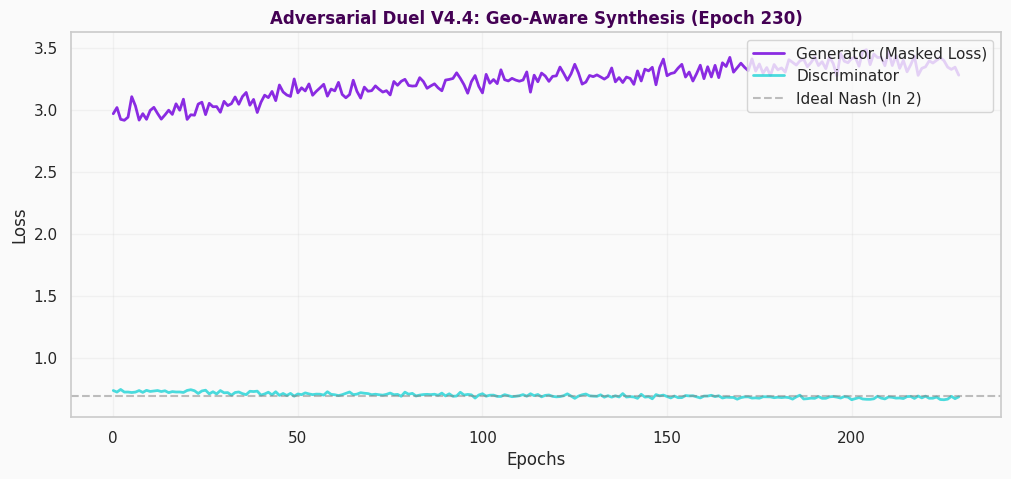

KeyboardInterrupt: 

In [16]:
# ==============================================================================
# CELL 10: THE SELF-HEALING FORGE (PIENZA V4.4 EXECUTION)
# ==============================================================================
# System: Pienza Intelligence Vault v4.4 (Geo-Aware & Masked)
# Purpose: Execute Training Loop using the Safe Stream defined in Cell 9.
# ==============================================================================
import os
import time
import joblib
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

# --- 1. CONFIGURACIÓN DE LA BÓVEDA (PHASE_4 ROOT) ---
VAULT_PATH  = '/content/drive/MyDrive/_Pienza/Assets/Phase_4/'
# Nombres actualizados a V4.4 para control de versiones
MODEL_FILE  = os.path.join(VAULT_PATH, 'pienza_generator_v3.5.keras')
SCALER_FILE = os.path.join(VAULT_PATH, 'pienza_physics_scaler_v3.5.pkl')
ENCODER_FILE = os.path.join(VAULT_PATH, 'pienza_label_encoders_v3.5.pkl')

if not os.path.exists(VAULT_PATH):
    os.makedirs(VAULT_PATH)
    print(f"📁 Directorio creado: {VAULT_PATH}")

print("🏛️ ACCEDIENDO A LA BÓVEDA PIENZA V4.4...")
print("-" * 65)

# --- 2. CONFIGURACIÓN DEL ENTRENAMIENTO ---
EPOCHS = 1000  # Puedes subir a 2000 si ves que sigue mejorando
history = {"gen_loss": [], "disc_loss": []}
start_forge_time = time.time()

print(f"🚀 INICIANDO SECUENCIA DE ENTRENAMIENTO (The Forge V4.4)...")
print(f"   - Arquitectura: Hybrid (Physics + Flags)")
print(f"   - Loss Strategy: Masked Reconstruction (Surge/Turbo)")
print(f"   - Target Epochs: {EPOCHS}")

# --- 3. EL BUCLE INFINITO (TRAINING LOOP) ---
for epoch in range(EPOCHS):
    start_epoch_time = time.time()
    epoch_gen_loss = []
    epoch_disc_loss = []

    # Ingestión del flujo cibernético (Preparado en la Cell 9)
    # dataset produce: (real_batch, real_switches)
    for batch_data, batch_switches in dataset:
        # Ejecutamos el paso de entrenamiento (Compilado en Cell 9)
        g_loss, d_loss = train_step(batch_data, batch_switches)

        epoch_gen_loss.append(g_loss)
        epoch_disc_loss.append(d_loss)

    # Registro de métricas promedio
    avg_g_loss = np.mean(epoch_gen_loss)
    avg_d_loss = np.mean(epoch_disc_loss)

    history["gen_loss"].append(avg_g_loss)
    history["disc_loss"].append(avg_d_loss)

    # --- 4. VISUALIZACIÓN EN TIEMPO REAL (HUD) ---
    if (epoch + 1) % 10 == 0: # Actualizamos cada 10 épocas
        clear_output(wait=True)
        elapsed_total = (time.time() - start_forge_time) / 60

        # Dashboard Textual
        print(f"⚒️  PIENZA FORGE V4.4: Epoch {epoch+1}/{EPOCHS}")
        print(f"   ⏱️  Tiempo Transcurrido: {elapsed_total:.2f} min")
        print(f"   🟣 Gen Loss (Creativity): {avg_g_loss:.4f}")
        print(f"   🟢 Disc Loss (Skepticism): {avg_d_loss:.4f}")

        # Interpretación Rápida
        if avg_d_loss < 0.1:
            status = "⚠️ CRÍTICO: Discriminador demasiado fuerte (Collapse Risk)"
        elif avg_d_loss > 1.5:
            status = "⚠️ CRÍTICO: Discriminador confundido (No aprende)"
        else:
            status = "✅ ESTABLE: Zona de Equilibrio de Nash"
        print(f"   📊 Estatus: {status}")

        # Gráfica de Duelo
        plt.figure(figsize=(12, 5))
        plt.plot(history["gen_loss"], label="Generator (Masked Loss)", color='#8A2BE2', linewidth=2)
        plt.plot(history["disc_loss"], label="Discriminator", color='#00CED1', linewidth=2, alpha=0.7)
        plt.axhline(y=0.693, color='grey', linestyle='--', label='Ideal Nash (ln 2)', alpha=0.5)

        plt.title(f"Adversarial Duel V4.4: Geo-Aware Synthesis (Epoch {epoch+1})", fontweight='bold')
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.legend(loc='upper right')
        plt.grid(True, alpha=0.2)
        plt.show()

# --- 5. PERSISTENCIA FINAL ---
print("\n🏁 FORJA FINALIZADA. Sellando inteligencia en el Vault...")

# Guardamos el Generador
generator.save(MODEL_FILE)

# Guardamos los Scalers y Encoders (Vital para decodificar después)
joblib.dump(physics_scaler, SCALER_FILE)
joblib.dump(label_encoders, ENCODER_FILE)

print(f"✅ Modelo guardado: {os.path.basename(MODEL_FILE)}")
print(f"✅ Scaler guardado: {os.path.basename(SCALER_FILE)}")
print(f"🏆 ESTATUS: LISTO PARA SIMULACIÓN (CELL 11).")

In [ ]:
# ==============================================================================
# CELL 11: THE MANIFOLD EXPLOSION v2 (THE 1,010,001 SYNTHESIS - FIXED)
# ==============================================================================
import pandas as pd
import numpy as np
import tensorflow as tf

# --- 1. CONFIGURATION ---
TOTAL_TARGET = 1_010_001
CHUNK_SIZE = 50_000
synthetic_batches = []

print(f"🌌 Sintetizando el Manifold Pienza ({TOTAL_TARGET:,} filas)...")

# --- 2. THE SYNTHESIS LOOP ---
num_batches = (TOTAL_TARGET // CHUNK_SIZE) + 1

for i in range(num_batches):
    current_done = len(synthetic_batches) * CHUNK_SIZE
    current_chunk = min(CHUNK_SIZE, TOTAL_TARGET - current_done)
    if current_chunk <= 0: break

    # A. Generar Ruido Latente
    noise = tf.random.normal([current_chunk, 100])

    # B. Muestrear Contextos Reales (Switches)
    sampled_indices = np.random.randint(0, df_gan_ready.shape[0], size=current_chunk)
    context_tensors = [
        tf.convert_to_tensor(df_gan_ready[col].values[sampled_indices].reshape(-1, 1), dtype=tf.float32)
        for col in SWITCH_COLS
    ]

    # C. INFERENCIA
    fake_physics = generator([noise] + context_tensors, training=False)

    # D. Empaquetar Batch
    chunk_df = pd.DataFrame(fake_physics.numpy(), columns=PHYSICS_COLS)

    # Re-insertar los Switches originales para el re-mapeo
    for idx, col in enumerate(SWITCH_COLS):
        chunk_df[col] = df_gan_ready[col].values[sampled_indices]

    synthetic_batches.append(chunk_df)
    if (i+1) % 4 == 0 or (i+1) == num_batches:
        print(f"   ⚡ Generando: {min((i+1)*CHUNK_SIZE, TOTAL_TARGET):,} / {TOTAL_TARGET:,}")

# --- 3. RECONSTRUCCIÓN DE LA REALIDAD ---
print("\n🛠️  Reconstruyendo unidades de la vida real...")
df_synthetic = pd.concat(synthetic_batches).reset_index(drop=True)
df_synthetic = df_synthetic.iloc[:TOTAL_TARGET]

# A. Invertir Escalamiento de Física (MinMax -> Log-Space)
df_synthetic[PHYSICS_COLS] = physics_scaler.inverse_transform(df_synthetic[PHYSICS_COLS])

# B. Invertir Transformación Logarítmica (Regreso a Pesos y Kilómetros)
# FIX: Aplicamos el exponencial directamente sobre las columnas originales
print("   📈 Invirtiendo escala Logarítmica...")
df_synthetic['upfront_fare'] = np.expm1(df_synthetic['upfront_fare'])
df_synthetic['est_trip_dist_km'] = np.expm1(df_synthetic['est_trip_dist_km'])

# C. Decodificar Switches (Índices -> Etiquetas reales)
print("   🧩 Decodificando etiquetas estratégicas...")
for col in SWITCH_COLS:
    le = label_encoders[col]
    df_synthetic[col] = df_synthetic[col].astype(int)
    df_synthetic[col] = df_synthetic[col].clip(0, len(le.classes_) - 1)
    df_synthetic[col] = le.inverse_transform(df_synthetic[col])

# --- 4. ENSAMBLAJE MOLECULAR (Derived Physics) ---
print("🧬 Ensamblando moléculas de Business Intelligence...")

# 1. EPH Operativo Sintético
# Evitamos división por cero en tiempos extremadamente bajos generados
safe_time = df_synthetic['est_trip_time_sec'].clip(lower=1)
df_synthetic['eph_operational'] = (df_synthetic['upfront_fare'] / (safe_time / 3600))

# 2. Vexation Index Sintético
df_synthetic['vexation_index'] = (df_synthetic['est_trip_time_sec'] / 60) / df_synthetic['est_trip_dist_km'].clip(lower=0.1)

print("\n✅ EL MANIFOLD PIENZA v2 ESTÁ COMPLETO.")
print(f"   - Muestra: {TOTAL_TARGET:,} filas.")
print(f"   - Fare Promedio: ${df_synthetic['upfront_fare'].mean():.2f}")
print(f"   - EPH Promedio:  ${df_synthetic['eph_operational'].mean():.2f}")

display(df_synthetic.sample(5))

In [ ]:
# ==============================================================================
# CELL 11.5: THE SOVEREIGN AUDIT (v2.1 - TYPE ALIGNED)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

def execute_manifold_audit_v21(df_real_source, df_synth_source):
    print("🔬 INICIANDO AUDITORÍA DIFERENCIAL (PIENZA MANIFOLD v2.1)")
    print("="*65)

    # 1. PREPARACIÓN DE LA REALIDAD (Sincronización con la Refinería)
    # Debemos aplicar las mismas fusiones a la realidad para comparar peras con peras
    df_real = df_real_source.copy()
    df_real['product_category_fk'] = df_real['product_category_fk'].replace(3, 2).replace(4, 3)
    df_real = df_real[df_real['product_category_fk'].isin([1, 2, 3])]
    df_real['reason_primary_fk'] = df_real['reason_primary_fk'].fillna(99)

    # 2. ALINEACIÓN DE TIPOS (Forzar todo a String para el censo)
    # Esto evita el error de Int vs Str
    real_prod_series = df_real['product_category_fk'].astype(int).astype(str)
    synth_prod_series = df_synth_source['product_category_fk'].astype(int).astype(str)

    # 3. AUDITORÍA DE PRODUCTOS
    print("📊 ANALIZANDO MIX DE PRODUCTOS (Hierarchy Check)...")
    real_mix = real_prod_series.value_counts(normalize=True).sort_index()
    synth_mix = synth_prod_series.value_counts(normalize=True).sort_index()

    # 4. AUDITORÍA VISUAL
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    plt.subplots_adjust(hspace=0.35)
    fig.suptitle('Manifold v2 Integrity Audit: Real (Teal) vs. Synthetic (Purple)',
                 fontsize=22, fontweight='bold', color=PIENZA_PURPLE)

    # --- PLOT 1: UPFRONT FARE DISTRIBUTION ---
    sns.kdeplot(df_real['upfront_fare'], ax=axes[0, 0], color=PIENZA_TEAL, fill=True, label='REAL', alpha=0.5)
    sns.kdeplot(df_synth_source['upfront_fare'], ax=axes[0, 0], color=PIENZA_PURPLE, fill=True, label='SYNTHETIC', alpha=0.5)
    axes[0, 0].set_title("Financial Physics: Upfront Fare PDF", fontweight='bold')
    axes[0, 0].set_xlim(0, 500)
    axes[0, 0].legend()

    # --- PLOT 2: TRIP DISTANCE DISTRIBUTION ---
    sns.kdeplot(df_real['est_trip_dist_km'], ax=axes[0, 1], color=PIENZA_TEAL, fill=True, label='REAL', alpha=0.5)
    sns.kdeplot(df_synth_source['est_trip_dist_km'], ax=axes[0, 1], color=PIENZA_PURPLE, fill=True, label='SYNTHETIC', alpha=0.5)
    axes[0, 1].set_title("Physical Space: Est. Trip Distance PDF", fontweight='bold')
    axes[0, 1].set_xlim(0, 40)
    axes[0, 1].legend()

    # --- PLOT 3: EPH BY CATEGORY ---
    # Usamos los IDs ya alineados
    sns.boxplot(data=df_synth_source, x='product_category_fk', y='eph_operational',
                palette="viridis", ax=axes[1, 0], showfliers=False)
    axes[1, 0].set_title("Synthetic Economic Hierarchy (EPH by Category)", fontweight='bold')
    axes[1, 0].set_xticklabels(['UberX (1)', 'Comfort (2)', 'Black (3)'])
    axes[1, 0].set_ylim(0, 800)

    # --- PLOT 4: STRATEGIC INTENT ---
    real_reasons = df_real['reason_primary_fk'].astype(float).astype(int).astype(str).value_counts(normalize=True).sort_index()
    synth_reasons = df_synth_source['reason_primary_fk'].astype(float).astype(int).astype(str).value_counts(normalize=True).sort_index()

    sns.barplot(x=synth_reasons.index, y=synth_reasons.values, color=PIENZA_PURPLE, alpha=0.6, ax=axes[1, 1], label='SYNTH')
    sns.barplot(x=real_reasons.index, y=real_reasons.values, color=PIENZA_TEAL, alpha=0.3, ax=axes[1, 1], label='REAL')
    axes[1, 1].set_title("Strategic Composition (Reason ID Distribution)", fontweight='bold')
    axes[1, 1].legend()

    plt.show()

    # --- REPORTE NUMÉRICO ---
    print("\n📈 REPORTE DE FIDELIDAD DE CATEGORÍAS (PRODUCTOS):")
    comparison = pd.DataFrame({'Real %': real_mix * 100, 'Synth %': synth_mix * 100})
    # Mapeo de nombres para el reporte
    prod_names = {'1': 'UberX', '2': 'Comfort', '3': 'Black'}
    comparison.index = comparison.index.map(prod_names)

    comparison['Delta %'] = comparison['Synth %'] - comparison['Real %']
    display(comparison.style.format("{:.2f}%"))

    print("\n🏁 AUDITORÍA FINALIZADA.")

# --- EJECUTAR ---
execute_manifold_audit_v21(df_raw, df_synthetic)

In [ ]:
# ==============================================================================
# CELL 11.6: PRICING HIERARCHY AUDIT (v2.2 - TYPE-SAFE EDITION)
# ==============================================================================
# Purpose: Direct comparison of Upfront Fare by category with strict type
#          alignment to prevent Int vs. Str conflicts.
# ==============================================================================

def execute_pricing_hierarchy_audit_v22(df_real_source, df_synth_source):
    print("💰 AUDITANDO JERARQUÍA DE PRECIOS: LA PRUEBA DEL LUJO (v2.2)")
    print("-" * 65)

    # 1. Preparación de la Realidad (Sincronización de IDs)
    df_real = df_real_source.copy()
    df_real['product_category_fk'] = df_real['product_category_fk'].replace(3, 2).replace(4, 3)
    df_real = df_real[df_real['product_category_fk'].isin([1, 2, 3])]

    # 2. ALINEACIÓN FORZOSA DE TIPOS (The Fix)
    # Convertimos ambas columnas a Int para que Pandas pueda agrupar sin errores
    real_prod = df_real['product_category_fk'].astype(int)
    synth_prod = df_synth_source['product_category_fk'].astype(int)

    # 3. Agrupación y Cálculo de Medias
    real_prices = df_real.groupby(real_prod)['upfront_fare'].mean()
    synth_prices = df_synth_source.groupby(synth_prod)['upfront_fare'].mean()

    # 4. Construcción del DataFrame Comparativo
    comparison_df = pd.DataFrame({
        'Real_Avg': real_prices,
        'Synth_Avg': synth_prices
    })

    # Mapeo de nombres para la visualización
    names = {1: 'UberX', 2: 'Comfort', 3: 'Black'}
    comparison_df.index = comparison_df.index.map(names)

    # Métricas de Error
    comparison_df['Delta ($)'] = comparison_df['Synth_Avg'] - comparison_df['Real_Avg']
    comparison_df['Fidelity (%)'] = (1 - abs(comparison_df['Delta ($)'] / comparison_df['Real_Avg'])) * 100

    # 5. VISUALIZACIÓN
    plt.figure(figsize=(14, 7))

    # Formatear para Seaborn
    plot_df = comparison_df.reset_index().melt(id_vars='product_category_fk',
                                               value_vars=['Real_Avg', 'Synth_Avg'],
                                               var_name='Universe', value_name='Avg_Fare')

    sns.barplot(data=plot_df, x='product_category_fk', y='Avg_Fare', hue='Universe',
                palette=[PIENZA_TEAL, PIENZA_PURPLE], edgecolor='#333333')

    plt.title("Pricing Hierarchy: Real vs. Synthetic Upfront Fare", fontweight='bold', fontsize=18)
    plt.ylabel("Average Fare ($ MXN)")
    plt.xlabel("Product Category")
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    # Anotaciones
    for p in plt.gca().patches:
        if p.get_height() > 0:
            plt.gca().annotate(f'${p.get_height():.1f}',
                               (p.get_x() + p.get_width() / 2., p.get_height()),
                               ha='center', va='center', xytext=(0, 10),
                               textcoords='offset points', fontweight='bold')

    plt.show()

    display(comparison_df.style.format("${:.2f}", subset=['Real_Avg', 'Synth_Avg', 'Delta ($)'])
                        .format("{:.2f}%", subset=['Fidelity (%)']))

# EJECUTAR
execute_pricing_hierarchy_audit_v22(df_raw, df_synthetic)

In [ ]:
# ==============================================================================
# CELL 11.7: DEEP AUDIT v2.4 - LOGISTICS & WEEKLY PULSE
# ==============================================================================
# Purpose: Final validation of the operational physics and weekly rhythm.
# Focus:   Access Logistics (TTP/DTP) and Weekly Value Alignment.
# ==============================================================================

def execute_refined_deep_audit(df_real_source, df_synth_source):
    print("🔬 INICIANDO AUDITORÍA DE LOGÍSTICA Y RITMO SEMANAL (v2.4)")
    print("="*80)

    # 1. PREPARACIÓN DE DATOS
    df_real = df_real_source.copy()
    df_real['offer_timestamp'] = pd.to_datetime(df_real['offer_timestamp'])
    df_real['day_of_week'] = df_real['offer_timestamp'].dt.day_name()
    df_real['time_to_pickup_min'] = df_real['time_to_pickup_sec'] / 60

    df_synth = df_synth_source.copy()
    df_synth['time_to_pickup_min'] = df_synth['time_to_pickup_sec'] / 60

    # 2. VISUALIZACIÓN (2x2 Grid)
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    plt.subplots_adjust(hspace=0.35, wspace=0.2)
    fig.suptitle('Manifold Integrity: Logistics & Weekly Value Pulse',
                 fontsize=26, fontweight='bold', color=PIENZA_PURPLE)

    # --- PLOT 1: DISTRIBUCIÓN TTP (Time to Pickup) ---
    sns.kdeplot(df_real['time_to_pickup_min'], ax=axes[0, 0], color=PIENZA_TEAL, fill=True, label='REAL', alpha=0.5)
    sns.kdeplot(df_synth['time_to_pickup_min'], ax=axes[0, 0], color=PIENZA_PURPLE, fill=True, label='SYNTH', alpha=0.5)
    axes[0, 0].set_title("Access Logistics: TTP Distribution", fontweight='bold')
    axes[0, 0].set_xlabel("Minutes to Pickup")
    axes[0, 0].set_xlim(0, 30)
    axes[0, 0].legend()

    # --- PLOT 2: DISTRIBUCIÓN DTP (Distance to Pickup) ---
    sns.kdeplot(df_real['dist_to_pickup_km'], ax=axes[0, 1], color=PIENZA_TEAL, fill=True, label='REAL', alpha=0.5)
    sns.kdeplot(df_synth['dist_to_pickup_km'], ax=axes[0, 1], color=PIENZA_PURPLE, fill=True, label='SYNTH', alpha=0.5)
    axes[0, 1].set_title("Access Logistics: DTP Distribution", fontweight='bold')
    axes[0, 1].set_xlabel("Distance to Pickup (km)")
    axes[0, 1].set_xlim(0, 15)
    axes[0, 1].legend()

    # --- PLOT 3: APPROACH VELOCITY (Regresión TTP vs DTP) ---
    # Muestreamos para no saturar el gráfico
    sns.regplot(data=df_real.sample(500), x='dist_to_pickup_km', y='time_to_pickup_sec',
                ax=axes[1, 0], scatter_kws={'alpha':0.2, 'color':PIENZA_TEAL},
                line_kws={'color':PIENZA_TEAL, 'label':'REAL_REG'})
    sns.regplot(data=df_synth.sample(500), x='dist_to_pickup_km', y='time_to_pickup_sec',
                ax=axes[1, 0], scatter_kws={'alpha':0.2, 'color':PIENZA_PURPLE},
                line_kws={'color':PIENZA_PURPLE, 'label':'SYNTH_REG'})
    axes[1, 0].set_title("Approach Velocity: Distance vs. Time to Pickup", fontweight='bold')
    axes[1, 0].set_xlabel("Distance to Pickup (km)")
    axes[1, 0].set_ylabel("Seconds to Pickup")

    # --- PLOT 4: RITMO SEMANAL (Día de la Semana) ---
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    real_day = df_real.groupby('day_of_week')['upfront_fare'].mean().reindex(day_order)
    synth_day = df_synth.groupby('day_of_week')['upfront_fare'].mean().reindex(day_order)

    axes[1, 1].bar(day_order, real_day, color=PIENZA_TEAL, alpha=0.3, label='REAL_AVG')
    axes[1, 1].plot(day_order, synth_day, color=PIENZA_PURPLE, marker='s', label='SYNTH_AVG', linewidth=3)
    axes[1, 1].set_title("Weekly Value Cycle: Avg Fare by Day", fontweight='bold')
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].set_ylabel("Avg Fare ($ MXN)")
    axes[1, 1].legend()

    plt.show()

    # --- REPORTE TÉCNICO DE VELOCIDAD ---
    print("\n🏎️  ESTADÍSTICAS DE VELOCIDAD DE ACERCAMIENTO (Avg Sec/Km):")
    real_vel = (df_real['time_to_pickup_sec'] / df_real['dist_to_pickup_km'].replace(0, np.nan)).mean()
    synth_vel = (df_synth['time_to_pickup_sec'] / df_synth['dist_to_pickup_km'].replace(0, np.nan)).mean()
    print(f"   - REAL:  {real_vel:.2f} sec/km")
    print(f"   - SYNTH: {synth_vel:.2f} sec/km")
    print(f"   - FIDELIDAD: { (1 - abs((synth_vel-real_vel)/real_vel))*100 :.2f}%")

    print("\n🏁 AUDITORÍA DE LOGÍSTICA FINALIZADA.")

# EJECUTAR
execute_refined_deep_audit(df_raw, df_synthetic)

In [ ]:
# ==============================================================================
# CELL 11.8.1: AUDIT - CIRCADIAN PULSE (ANTI-MIXED TYPE EDITION)
# ==============================================================================

def execute_hourly_pulse_audit_final(df_real_source, df_synth_source):
    print("⏰ INICIANDO AUDITORÍA DEL PULSO CIRCADIANO (Eje Ordenado)")
    print("="*70)

    # 1. PREPARACIÓN DE DATOS (Real)
    df_real = df_real_source.copy().dropna(subset=['offer_timestamp'])
    df_real['hour_of_day'] = pd.to_datetime(df_real['offer_timestamp']).dt.hour

    # 2. PREPARACIÓN DE DATOS (Synthetic)
    df_synth = df_synth_source.copy()

    # --- FILTRO CRÍTICO ---
    # Eliminamos cualquier NaN o tipo no numérico del índice para prevenir el TypeError
    df_synth['hour_of_day'] = pd.to_numeric(df_synth['hour_of_day'], errors='coerce').dropna().astype(int)

    # 3. CALCULO DE PROMEDIOS
    # El índice (hour_of_day) ya es puramente numérico
    real_hour = df_real.groupby('hour_of_day')['upfront_fare'].mean()
    synth_hour = df_synth.groupby('hour_of_day')['upfront_fare'].mean()

    # 4. ALINEACIÓN DE EJES (Respeta la discontinuidad de horas)
    # Creamos un eje común que respeta tu ventana operativa (5 a 22)
    min_hour = min(real_hour.index.min(), synth_hour.index.min())
    max_hour = max(real_hour.index.max(), synth_hour.index.max())

    all_hours = pd.Index(range(min_hour, max_hour + 1))

    # Reindexamos con ceros para las horas sin datos (manteniendo la discontinuidad)
    comparison_df = pd.DataFrame({
        'REAL': real_hour.reindex(all_hours, fill_value=np.nan),
        'SYNTHETIC': synth_hour.reindex(all_hours, fill_value=np.nan)
    })

    # 5. VISUALIZACIÓN
    fig, ax = plt.subplots(figsize=(16, 7))
    fig.suptitle('Manifold Integrity: Circadian Value Pulse (Order & Discontinuity Fixed)',
                 fontsize=22, fontweight='bold', color=PIENZA_PURPLE)

    # Usamos plot en lugar de scatter para manejar la línea continua entre los puntos existentes
    ax.plot(comparison_df.index, comparison_df['REAL'], color=PIENZA_TEAL, marker='o',
            label='REAL (Ground Truth)', linewidth=3)
    ax.plot(comparison_df.index, comparison_df['SYNTHETIC'], color=PIENZA_PURPLE, marker='s',
            label='SYNTHETIC (Manifold)', linestyle='--', linewidth=2)

    ax.set_title("Avg Fare by Hour (Discontinuidades respetadas)", fontweight='bold')
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Avg Upfront Fare ($ MXN)")
    ax.set_xticks(comparison_df.index)
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.show()

    # 6. REPORTE NUMÉRICO
    print("\n📈 REPORTE NUMÉRICO (REAL vs. SYNTH):")
    comparison_df['Delta %'] = (comparison_df['SYNTHETIC'] - comparison_df['REAL']) / comparison_df['REAL'] * 100
    display(comparison_df.style.format("${:.2f}", subset=['REAL', 'SYNTHETIC']).format("{:.2f}%", subset=['Delta %']))

# EJECUTAR
execute_hourly_pulse_audit_final(df_raw, df_synthetic)

In [ ]:
# ==============================================================================
# CELL 11.9: AUDIT - REWARD MAGNITUDE CONSISTENCY CHECK
# ==============================================================================
# Purpose: Compare the average monetary value of all reward columns.
# Logic:   Verify the GAN learned the value hierarchy: Reservation > Turbo > Surge.
# ==============================================================================

def execute_reward_magnitude_audit(df_real_source, df_synth_source):
    print("💰 AUDITORÍA DE MAGNITUD DE RECOMPENSAS (Consistency Check)")
    print("="*80)

    # Definición de las columnas de recompensa (solo montos)
    reward_cols = ['surge_amount', 'turbo_plus_amount', 'reservation_amount', 'priority_amount']

    # 1. PREPARACIÓN DE LA REALIDAD (Medias de las cantidades activas)
    # Filtramos por > 0 para ver solo el valor del incentivo cuando está ACTIVO
    df_real_active = df_real_source[reward_cols].replace(0, np.nan).dropna(axis=0, how='all')
    df_synth_active = df_synth_source[reward_cols].replace(0, np.nan).dropna(axis=0, how='all')

    # Calculamos la media SÓLO para los valores > 0
    real_means = df_real_active.mean()
    synth_means = df_synth_active.mean()

    # 2. CONSTRUCCIÓN DEL DATASET DE COMPARACIÓN
    comparison_df = pd.DataFrame({
        'REAL': real_means,
        'SYNTH': synth_means
    }).reset_index()
    comparison_df.columns = ['Incentive', 'Real_Avg', 'Synth_Avg']

    # 3. VISUALIZACIÓN
    plt.figure(figsize=(14, 7))

    sns.barplot(x='Incentive', y='Real_Avg', data=comparison_df, color=PIENZA_TEAL, alpha=0.7, label='REAL')
    sns.barplot(x='Incentive', y='Synth_Avg', data=comparison_df, color=PIENZA_PURPLE, alpha=0.7, label='SYNTH')

    plt.title("Reward Magnitude: Mean Value When Active", fontweight='bold', fontsize=18)
    plt.ylabel("Average Amount ($ MXN)")
    plt.xlabel("Incentive Type")
    plt.legend()
    plt.grid(axis='y', alpha=0.3)

    # 4. REPORTE NUMÉRICO
    comparison_df['Delta %'] = (comparison_df['Synth_Avg'] - comparison_df['Real_Avg']) / comparison_df['Real_Avg'] * 100
    display(comparison_df.style.format("${:.2f}", subset=['Real_Avg', 'Synth_Avg']).format("{:.2f}%", subset=['Delta %']))

# EJECUTAR
execute_reward_magnitude_audit(df_raw, df_synthetic)

In [ ]:
# ==============================================================================
# CELL 11.10: AUDIT - TOPOLOGICAL DENSITY & FREQUENCY (REPORT ONLY)
# ==============================================================================
# Purpose: Final numeric audit of geographic fidelity (Frequency).
# ==============================================================================

def execute_topological_audit_report(df_real_source, df_synth_source):
    print("🗺️  INICIANDO AUDITORÍA DE DENSIDAD GEOGRÁFICA (Reporte Final)")
    print("="*80)

    # 1. PREPARACIÓN DE LA REALIDAD
    df_real = df_real_source.copy()

    # Inyección de Mapa Canónico (para hacer la comparación 1:1)
    id_map = {-1:-1, 41: 0, 42: 0, 46: 0, 43: 1, 65: 2, 62: 2, 44: 2, 36: 2, 49: 3, 52: 3, 35: 3, 50: 4, 58: 4, 25: 5, 31: 5, 63: 6, 39: 6, 51: 7, 33: 7, 37: 8, 53: 8, 48: 8, 60: 9, 57: 10, 12: 10, 32: 10, 24: 11, 40: 12, 45: 13, 59: 13, 61: 14, 38: 14, 34: 15, 30: 16, 66: 16, 17: 17, 14: 17, 22: 17, 16: 18, 13: 18, 11: 19, 15: 20, 21: 21, 20: 21, 19: 21, 18: 22, 47: 23, 55: 23, 56: 23, 54: 24, 64: 24, 71: 25, 9: 26, 70: 27, 69: 28, 8: 29, 6: 30, 7: 30, 23: 30, 3: 31, 2: 32, 4: 33, 29: 33, 68: 34, 5: 35, 27: 36, 28: 36, 1: 37, 10: 38, 0: 39, 26: 40, 67: 41}
    df_real['id_agrupado'] = df_real['dropoff_polygon_id'].fillna(-1).astype(int).map(id_map).fillna(-1)
    conditions_id = [ (df_real['id_agrupado'] >= 0), (df_real['dropoff_hdbscan_id'] > -1) ]
    choices_id = [ "P_" + df_real['id_agrupado'].astype(str), "C_" + df_real['dropoff_hdbscan_id'].astype(str) ]
    df_real['dropoff_zone_id'] = np.select(conditions_id, choices_id, default="Unassigned")

    # 2. CÁLCULO DE FRECUENCIA
    df_synth = df_synth_source.copy()

    real_freq = df_real['dropoff_zone_id'].value_counts(normalize=True).mul(100).rename('Real %')
    synth_freq = df_synth_source['dropoff_zone_id'].value_counts(normalize=True).mul(100).rename('Synth %')

    # 3. CONSOLIDACIÓN DEL REPORTE FINAL
    audit_df = pd.concat([real_freq, synth_freq], axis=1).fillna(0)
    audit_df['Delta Abs'] = np.abs(audit_df['Real %'] - audit_df['Synth %'])

    # Formateo
    report_df = audit_df.sort_values(by='Delta Abs', ascending=False)

    # 4. REPORTE NUMÉRICO
    print("\n📊 REPORTE DE DENSIDAD GEOGRÁFICA (Top Deltas):")
    display(report_df.style.format({'Real %': '{:.2f}%', 'Synth %': '{:.2f}%', 'Delta Abs': '{:.2f}%'}))

    print("-" * 80)
    print(f"SUMA DE DESVIACIÓN ABSOLUTA TOTAL: {report_df['Delta Abs'].sum():.2f}%")
    print("🏁 AUDITORÍA TOPOLÓGICA FINALIZADA.")

# EJECUTAR
execute_topological_audit_report(df_raw, df_synthetic)

In [ ]:
# ==============================================================================
# CELL 12: PERSISTENCE (Saving the Manifold to the Data Lakehouse)
# ==============================================================================
import os

SAVE_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_4/pienza_manifold_v2.parquet'

def persist_manifold():
    print(f"💾 Forging Parquet file: {SAVE_PATH}...")

    try:
        # We save as Parquet for BigQuery efficiency
        df_synthetic.to_parquet(SAVE_PATH, index=False)

        file_size_gb = os.path.getsize(SAVE_PATH) / (1024**3)

        print(f"\n✅ MANIFOLD PERSISTED.")
        print(f"   - File Size: {file_size_gb:.2f} GB")
        print(f"   - Location:  {SAVE_PATH}")
        print("\n🚀 The Arena is ready for the Simulation.")

    except Exception as e:
        print(f"❌ Persistence Failed: {e}")

# EXECUTE
persist_manifold()